In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')  
from load_data import load_csv


In [2]:
# Load the datasets
train = load_csv("esa_train.csv")
test = load_csv("esa_test.csv")

# Basic info
print(f"Training set: {len(train):,} rows, {len(train.columns)} columns")
print(f"Test set: {len(test):,} rows, {len(test.columns)} columns")
print(f"\nUnique events: {train['event_id'].nunique():,}")
print(f"Unique missions: {train['mission_id'].nunique()}")

# Show first few rows
train.head()


Loading esa_train.csv...

esa_train.csv INFO:
Shape: (162634, 103)

Columns:
['event_id', 'time_to_tca', 'mission_id', 'risk', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed', 'relative_position_r', 'relative_position_t', 'relative_position_n', 'relative_velocity_r', 'relative_velocity_t', 'relative_velocity_n', 't_time_lastob_start', 't_time_lastob_end', 't_recommended_od_span', 't_actual_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_weighted_rms', 't_rcs_estimate', 't_cd_area_over_mass', 't_cr_area_over_mass', 't_sedr', 't_j2k_sma', 't_j2k_ecc', 't_j2k_inc', 't_ct_r', 't_cn_r', 't_cn_t', 't_crdot_r', 't_crdot_t', 't_crdot_n', 't_ctdot_r', 't_ctdot_t', 't_ctdot_n', 't_ctdot_rdot', 't_cndot_r', 't_cndot_t', 't_cndot_n', 't_cndot_rdot', 't_cndot_tdot', 'c_object_type', 'c_time_lastob_start', 'c_time_lastob_end', 'c_recommended_od_span', 'c_actual_od_span', 'c_obs_available', 'c_obs_used', 'c_residuals_accepted', 'c_weighted_rms', 'c_rc

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,...,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,...,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,...,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,...,0.022066,57.993905,0.003298,0.164309,0.002918,0.386400,89.0,83.0,40.0,14.0
4,0,0.257806,5,-10.391260,-7.852942,9.036838,14510.0,13792.0,478.7,5811.1,...,0.015075,57.946717,0.003670,0.164172,0.003220,0.386388,89.0,83.0,40.0,14.0


TARGET VARIABLE: risk
count    162634.000000
mean        -19.340603
std          10.011641
min         -30.000000
25%         -30.000000
50%         -17.870632
75%          -9.173294
max          -1.442854
Name: risk, dtype: float64


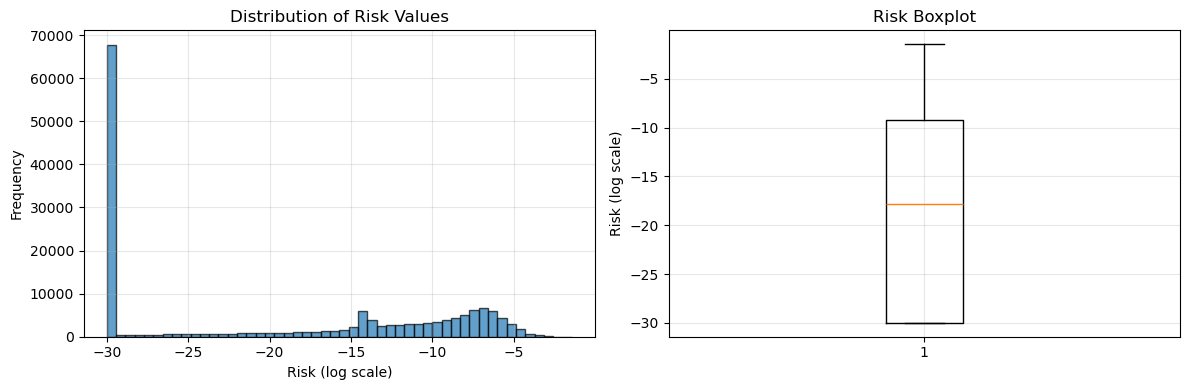

In [3]:
# Understanding the target variable: risk
print("TARGET VARIABLE: risk")
print("="*50)
print(train['risk'].describe())

# Plot distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train['risk'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Risk (log scale)')
plt.ylabel('Frequency')
plt.title('Distribution of Risk Values')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(train['risk'])
plt.ylabel('Risk (log scale)')
plt.title('Risk Boxplot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Check missing values for key columns
print("MISSING VALUES ANALYSIS")
print("="*50)

# Check important columns
key_cols = ['risk', 'miss_distance', 'relative_speed', 
            't_j2k_sma', 't_cd_area_over_mass', 'c_object_type',
            'F10', 'AP', 't_rcs_estimate', 'c_rcs_estimate']

missing_info = []
for col in key_cols:
    missing = train[col].isnull().sum()
    missing_pct = (missing / len(train)) * 100
    missing_info.append({
        'Column': col,
        'Missing': missing,
        'Percent': f"{missing_pct:.1f}%"
    })

missing_df = pd.DataFrame(missing_info)
print(missing_df)

MISSING VALUES ANALYSIS
                Column  Missing Percent
0                 risk        0    0.0%
1        miss_distance        0    0.0%
2       relative_speed        0    0.0%
3            t_j2k_sma        0    0.0%
4  t_cd_area_over_mass        0    0.0%
5        c_object_type        0    0.0%
6                  F10     6822    4.2%
7                   AP     6822    4.2%
8       t_rcs_estimate     3277    2.0%
9       c_rcs_estimate    52841   32.5%


In [5]:
# Understanding time series structure (for LSTM)
print("TIME SERIES STRUCTURE")
print("="*50)

# How many CDMs per event?
cdms_per_event = train.groupby('event_id').size()
print(f"\nCDMs per event:")
print(cdms_per_event.describe())

# Events per mission (for GNN)
events_per_mission = train.groupby('mission_id')['event_id'].nunique()
print(f"\nEvents per mission:")
print(events_per_mission.describe())
print(f"\nMission distribution:")
print(events_per_mission.sort_values(ascending=False))

TIME SERIES STRUCTURE

CDMs per event:
count    13154.000000
mean        12.363844
std          7.512551
min          1.000000
25%          5.000000
50%         13.000000
75%         20.000000
max         23.000000
dtype: float64

Events per mission:
count      19.000000
mean      692.315789
std       818.642647
min         8.000000
25%        56.500000
50%       265.000000
75%      1302.500000
max      2322.000000
Name: event_id, dtype: float64

Mission distribution:
mission_id
1     2322
5     2253
15    1769
7     1765
2     1497
6     1108
19     671
3      486
9      410
4      265
10     163
18     120
16     115
20      70
22      43
24      40
23      38
14      11
13       8
Name: event_id, dtype: int64


MISS_DISTANCE vs RISK
Correlation: -0.1583


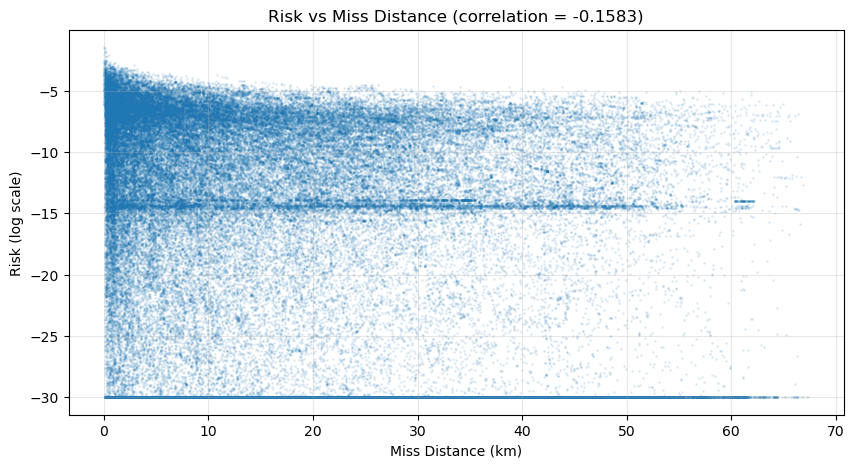

In [6]:
# Relationship between miss_distance and risk
print("MISS_DISTANCE vs RISK")
print("="*50)

correlation = train[['miss_distance', 'risk']].corr().iloc[0, 1]
print(f"Correlation: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(train['miss_distance']/1000, train['risk'], alpha=0.1, s=1)
plt.xlabel('Miss Distance (km)')
plt.ylabel('Risk (log scale)')
plt.title(f'Risk vs Miss Distance (correlation = {correlation:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

RELATIVE_SPEED vs RISK
Correlation: -0.0600


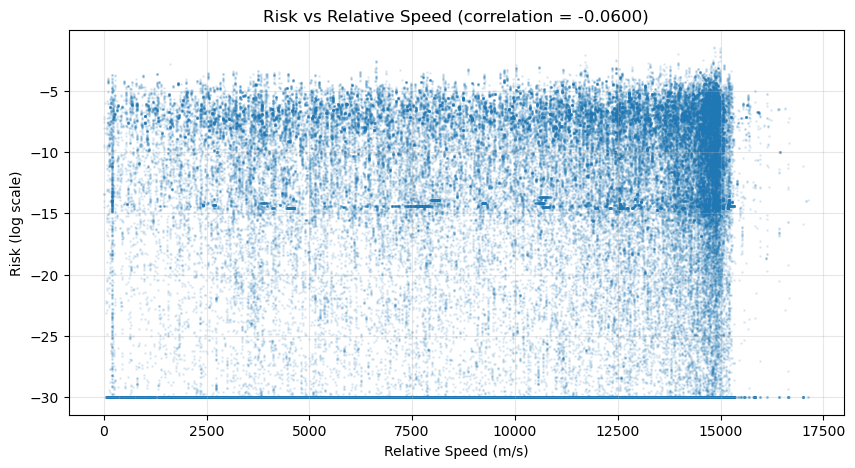

In [7]:
# Relationship between relative_speed and risk
print("RELATIVE_SPEED vs RISK")
print("="*50)

correlation = train[['relative_speed', 'risk']].corr().iloc[0, 1]
print(f"Correlation: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(train['relative_speed'], train['risk'], alpha=0.1, s=1)
plt.xlabel('Relative Speed (m/s)')
plt.ylabel('Risk (log scale)')
plt.title(f'Risk vs Relative Speed (correlation = {correlation:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Verify multimodal data exists
print("MULTIMODAL DATA VERIFICATION")
print("="*50)

print("\n1. ORBITAL PARAMETERS:")
orbital_cols = ['t_j2k_sma', 't_j2k_ecc', 't_j2k_inc']
for col in orbital_cols:
    print(f"  {col}: {train[col].notna().sum():,} values")

print("\n2. PHYSICAL PROPERTIES:")
physical_cols = ['t_cd_area_over_mass', 'c_cd_area_over_mass', 'c_object_type']
for col in physical_cols:
    print(f"  {col}: {train[col].notna().sum():,} values")

print("\n3. SPACE WEATHER:")
weather_cols = ['F10', 'AP']
for col in weather_cols:
    coverage = (train[col].notna().sum() / len(train)) * 100
    print(f"  {col}: {train[col].notna().sum():,} values ({coverage:.1f}% coverage)")

print("\n CONFIRMED: Dataset contains multimodal data!")
print("   - Orbital mechanics (position, velocity)")
print("   - Physical properties (mass, area, type)")
print("   - Space weather (solar flux, geomagnetic)")

MULTIMODAL DATA VERIFICATION

1. ORBITAL PARAMETERS:
  t_j2k_sma: 162,634 values
  t_j2k_ecc: 162,634 values
  t_j2k_inc: 162,634 values

2. PHYSICAL PROPERTIES:
  t_cd_area_over_mass: 162,634 values
  c_cd_area_over_mass: 162,634 values
  c_object_type: 162,634 values

3. SPACE WEATHER:
  F10: 155,812 values (95.8% coverage)
  AP: 155,812 values (95.8% coverage)

 CONFIRMED: Dataset contains multimodal data!
   - Orbital mechanics (position, velocity)
   - Physical properties (mass, area, type)
   - Space weather (solar flux, geomagnetic)


OBJECT TYPE DISTRIBUTION

Chaser object types:
c_object_type
DEBRIS         94470
UNKNOWN        50542
PAYLOAD        15498
ROCKET BODY     1947
TBA              177
Name: count, dtype: int64

Percentages:
c_object_type
DEBRIS         58.087485
UNKNOWN        31.077143
PAYLOAD         9.529373
ROCKET BODY     1.197167
TBA             0.108833
Name: proportion, dtype: float64


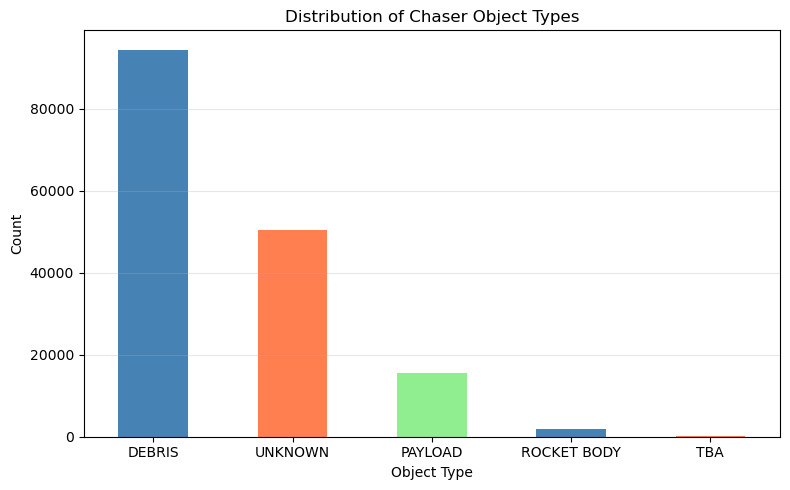

In [10]:
# Object type distribution
print("OBJECT TYPE DISTRIBUTION")
print("="*50)

print("\nChaser object types:")
print(train['c_object_type'].value_counts())
print("\nPercentages:")
print(train['c_object_type'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 5))
train['c_object_type'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'lightgreen'])
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.title('Distribution of Chaser Object Types')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()